In [1]:
# subcluster level roc curves 

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_with_mean_curve(subcluster, subcluster_name, color='blue', save_dir=None):
    plt.figure(figsize=(8, 6))
    base_path = f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_genes_subcluster_new/{subcluster}'
    missing = [i for i in range(1, 6) if not os.path.exists(os.path.join(base_path, f'split_{i}', 'test_predictions.csv'))]; print(f" {subcluster_name}: Missing splits {missing}" if missing else f" {subcluster_name}: All splits present")
    mean_fpr = np.linspace(0, 1, 100)
    all_tprs = []
    all_aucs = []

    for i in range(1, 6):
        pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
        if not os.path.exists(pred_file):
            print(f"⚠️  Missing: {pred_file}")
            continue

        df = pd.read_csv(pred_file)
        y_true = df['true_label']
        y_score = df['predicted_proba']

        if len(np.unique(y_true)) < 2:
            print(f"⚠️  Split {i} has only one class — skipping")
            continue

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        all_aucs.append(roc_auc)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        all_tprs.append(interp_tpr)

        plt.plot(fpr, tpr, color=color, alpha=0.3)

    # Plot mean curve
    if all_tprs:
        mean_tpr = np.mean(all_tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.mean(all_aucs)
        std_auc = np.std(all_aucs)

        plt.plot(mean_fpr, mean_tpr, color=color, linewidth=2.5,
                 label=f'Mean ROC (AUC: {mean_auc:.3f} ± {std_auc:.3f})')

    # Plot settings
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(subcluster_name, fontsize=16, weight='bold')
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

    # Save
    save_dir = f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/{subcluster}"
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, f'{subcluster_name}_roc_curve.png'), dpi=300)

    plt.show()
    plt.close()
    
    return np.mean(all_aucs) if all_aucs else None

 Astrocytes 0: All splits present


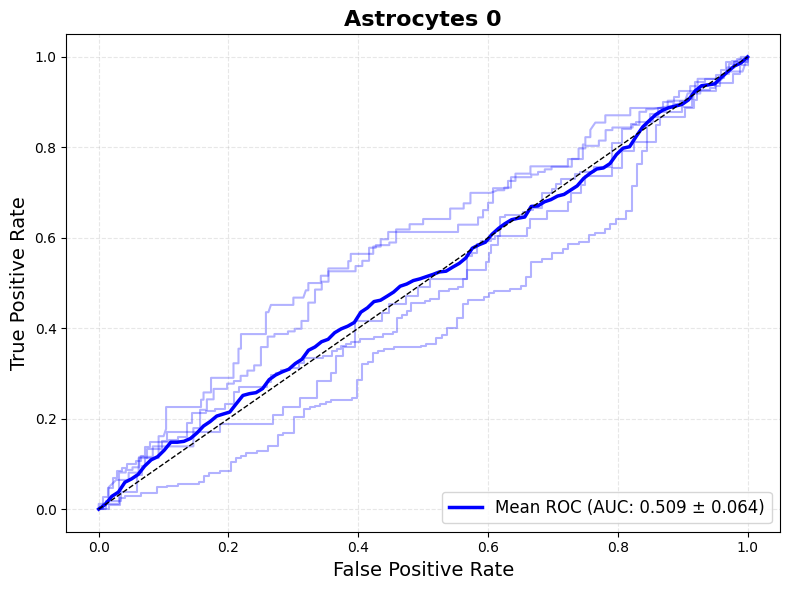

 Astrocytes 1: All splits present


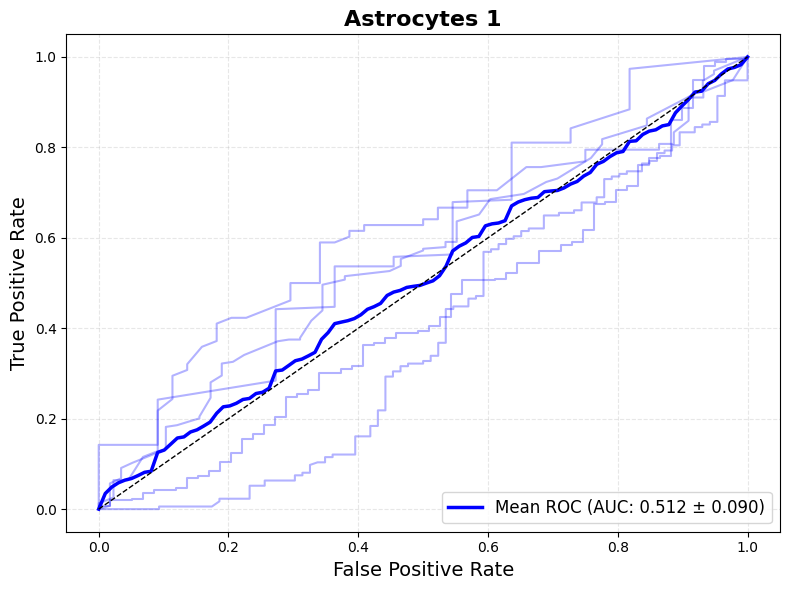

 Astrocytes 2: All splits present


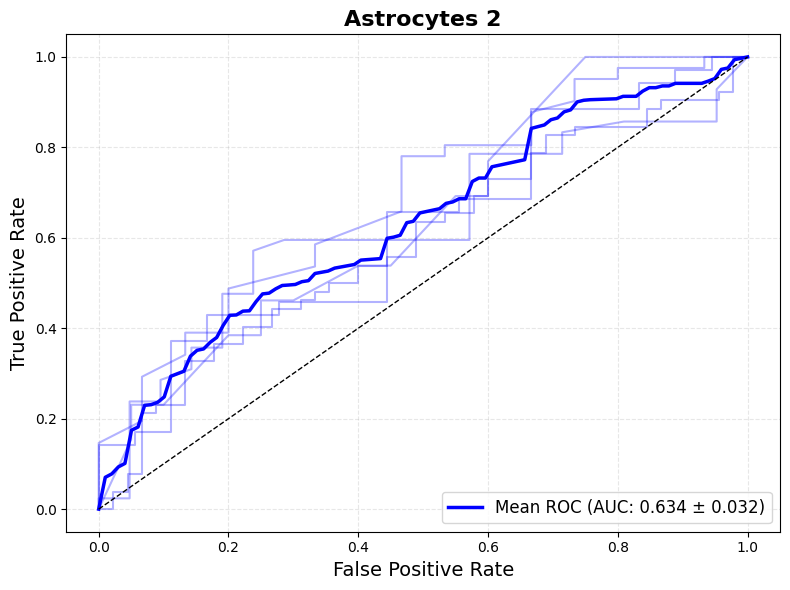

 Astrocytes 3: All splits present


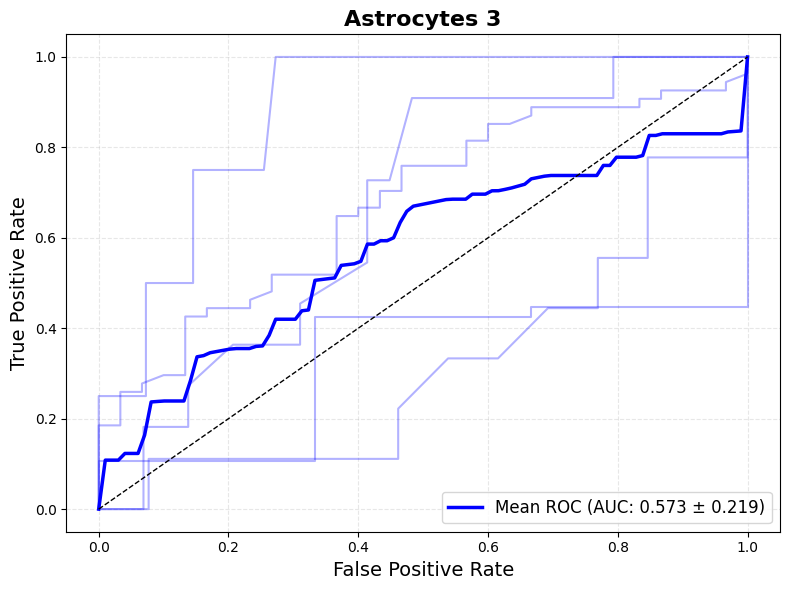

 Excitatory 0: All splits present


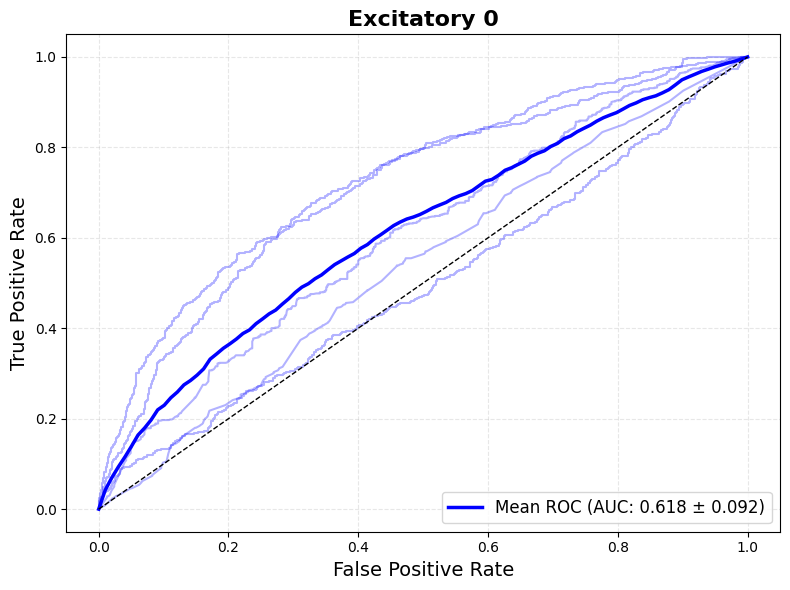

 Excitatory 1: All splits present


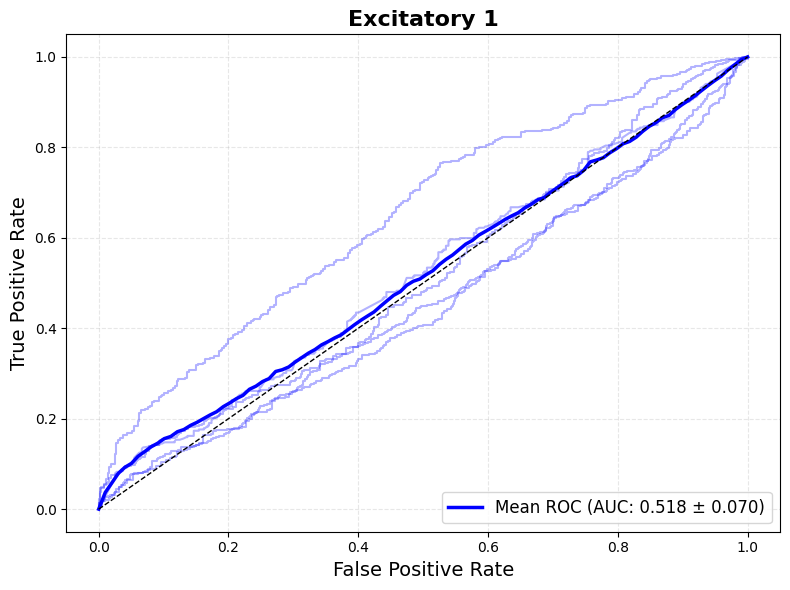

 Excitatory 2: All splits present


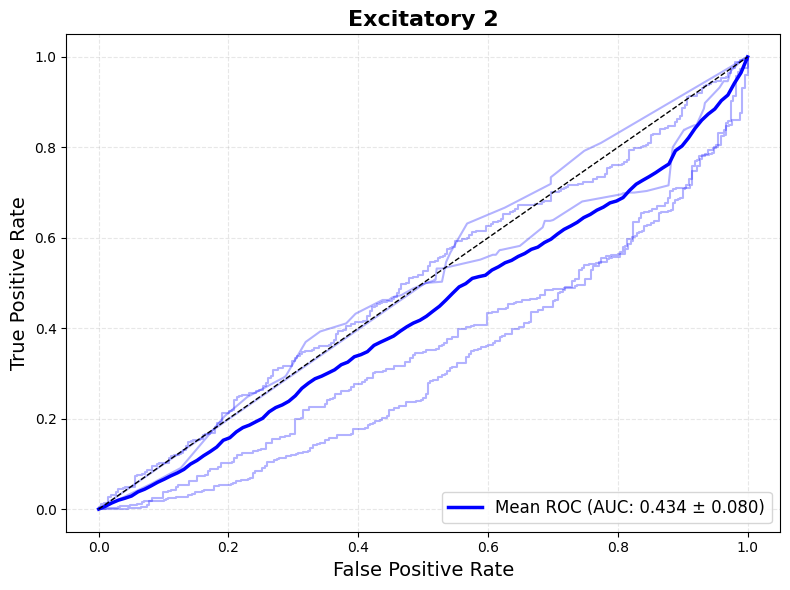

 Excitatory 3: All splits present


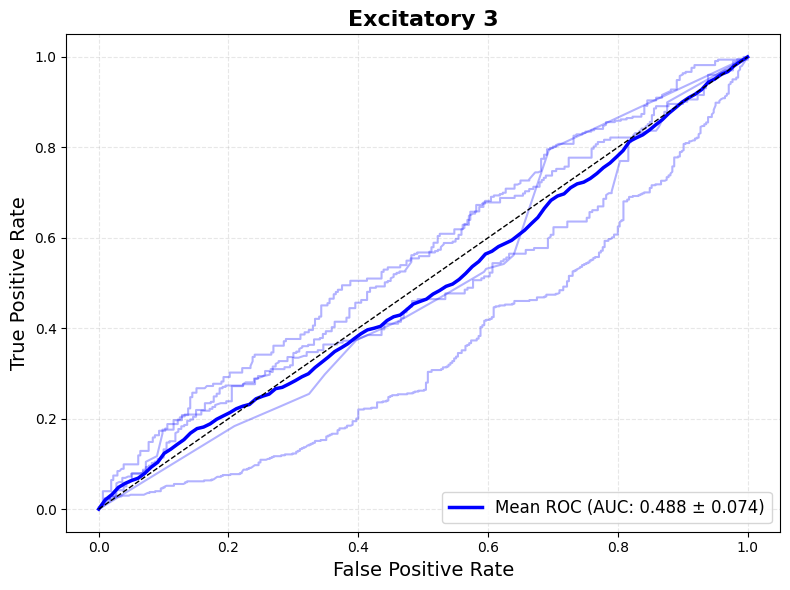

 Excitatory 4: All splits present


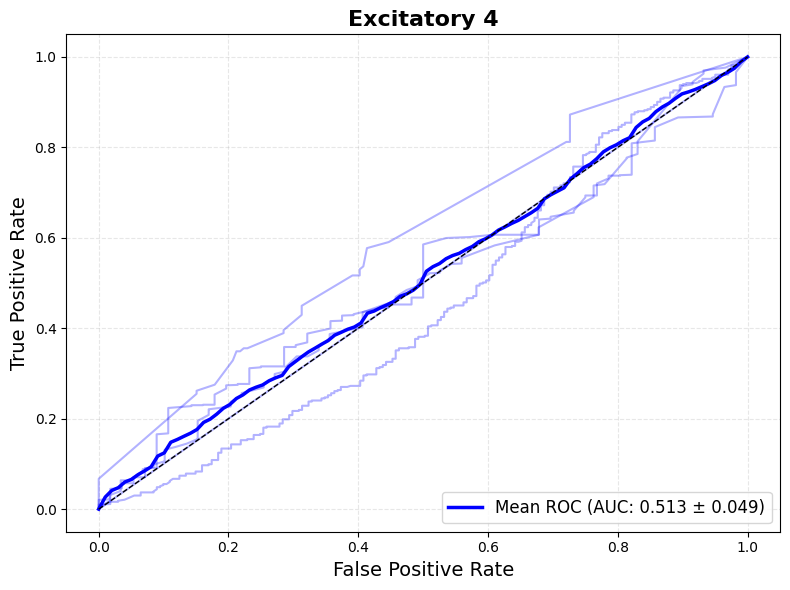

 Excitatory 5: All splits present


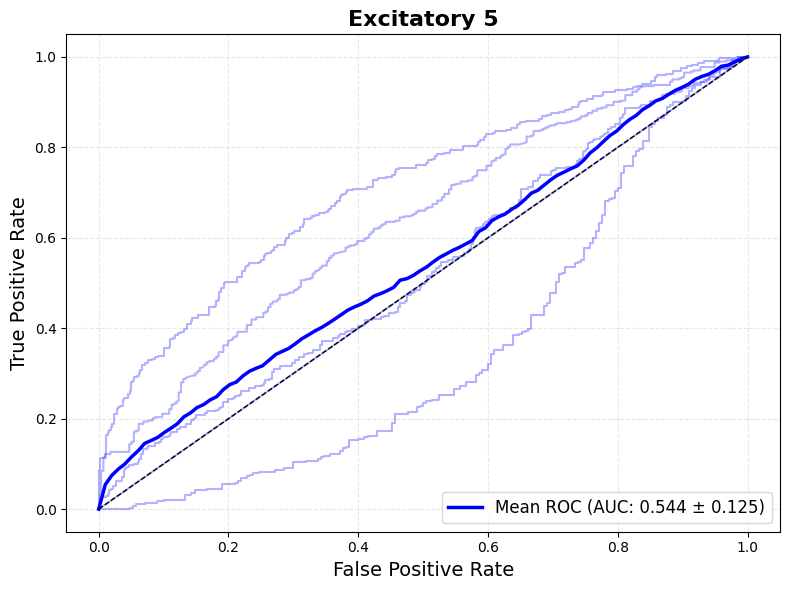

 Excitatory 6: All splits present


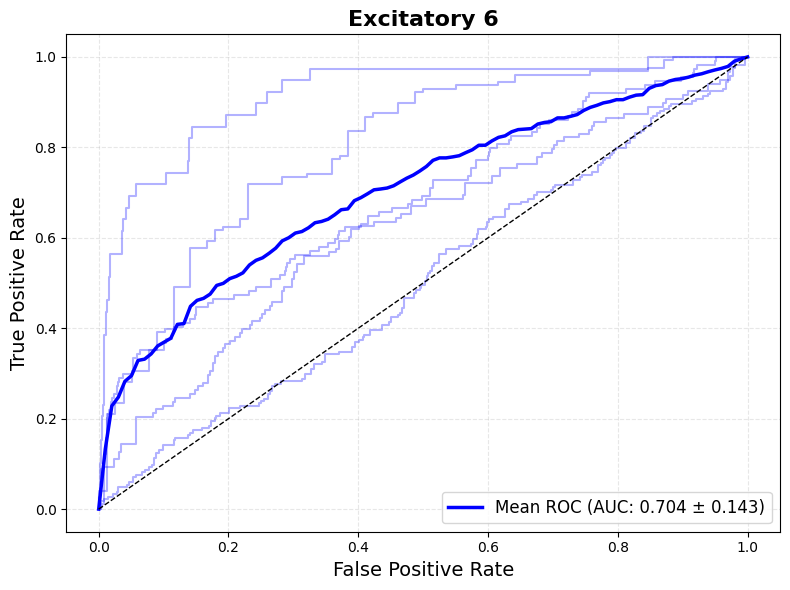

 Excitatory 7: All splits present


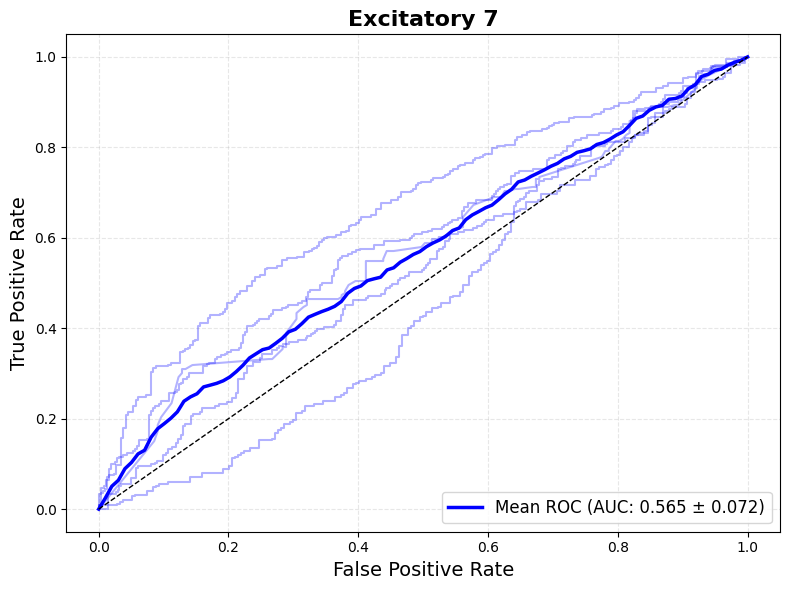

 Excitatory 8: All splits present


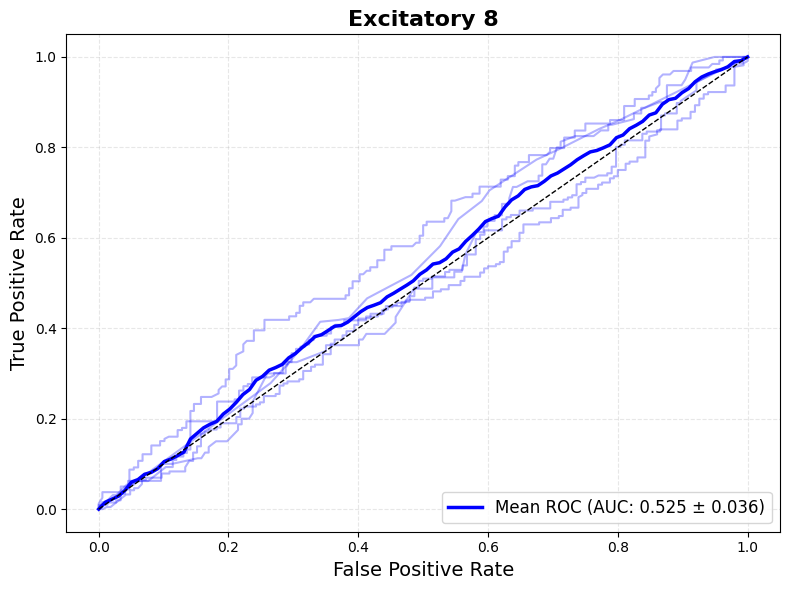

 Excitatory 9: All splits present


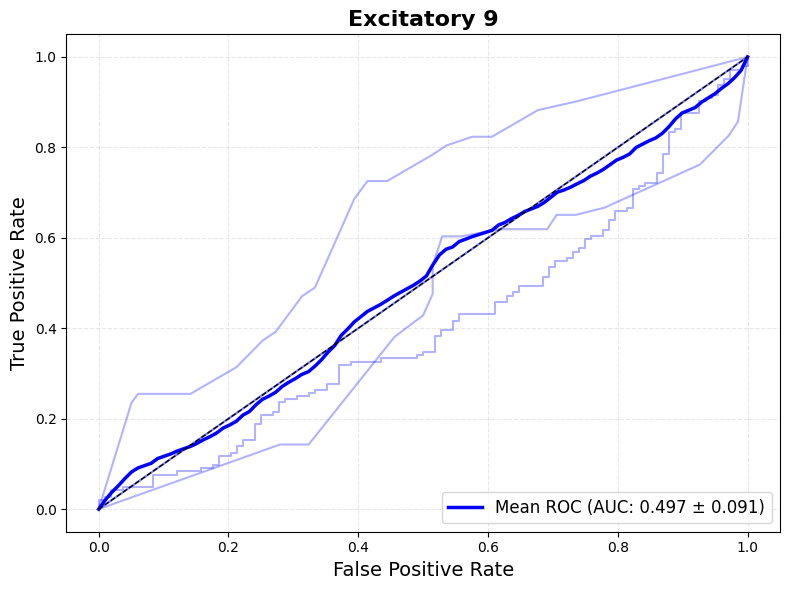

 Excitatory 11: All splits present


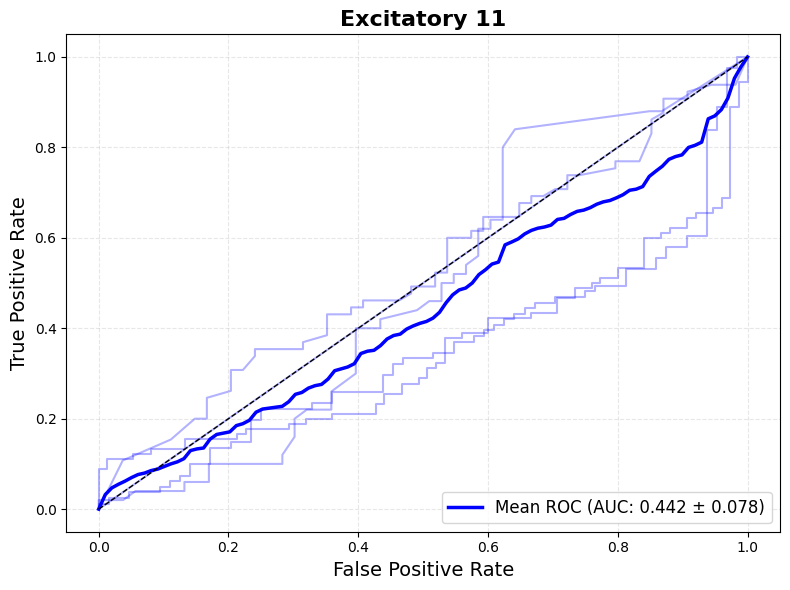

 Excitatory 12: All splits present


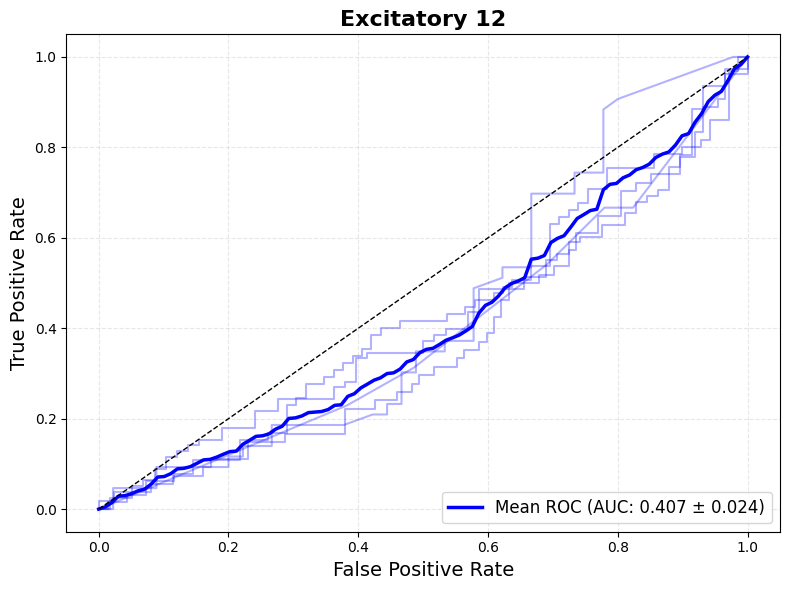

 Excitatory 14: All splits present


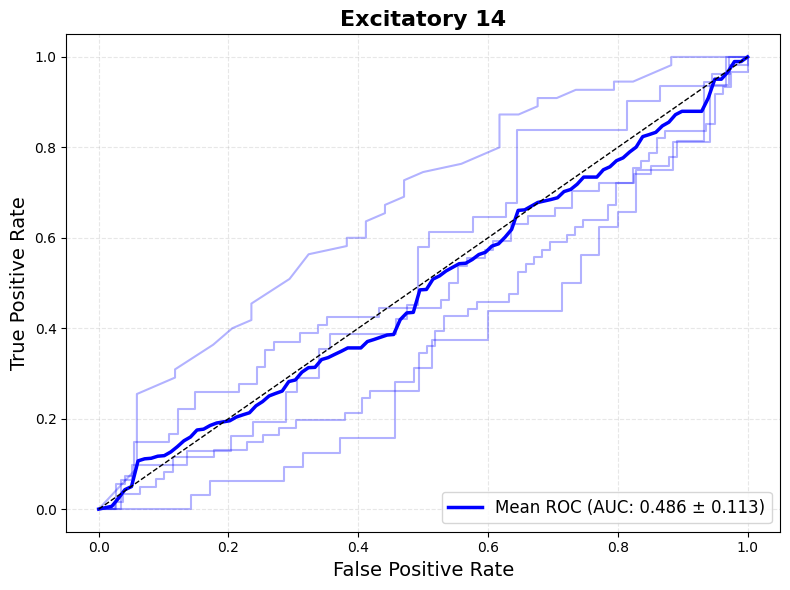

 Inhibitory 0: All splits present


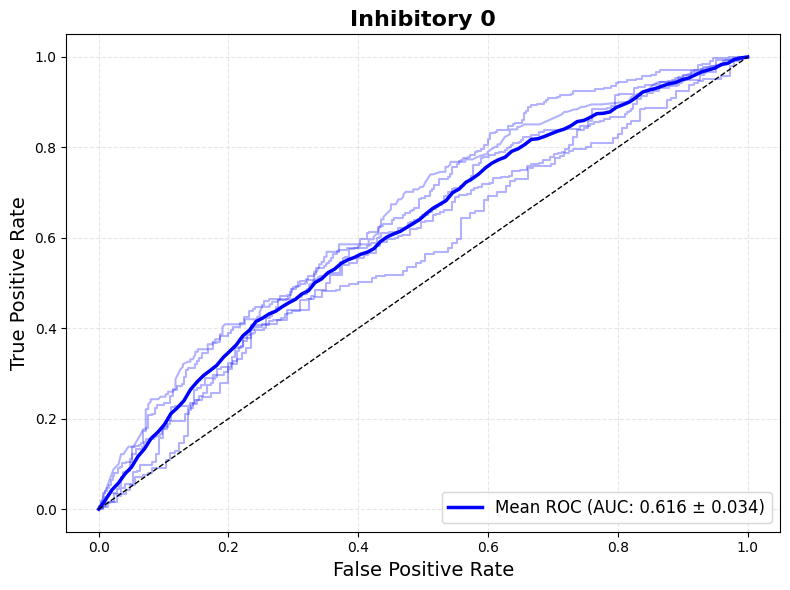

 Inhibitory 1: All splits present


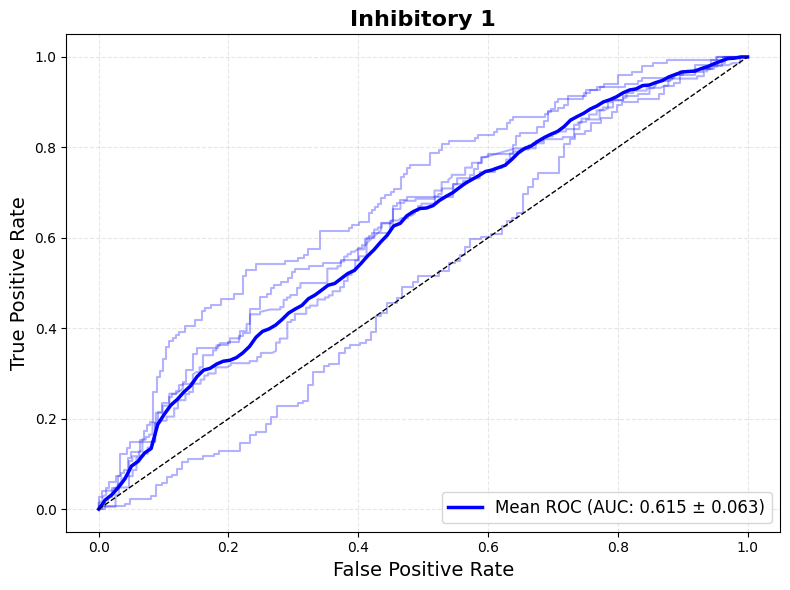

 Inhibitory 2: All splits present


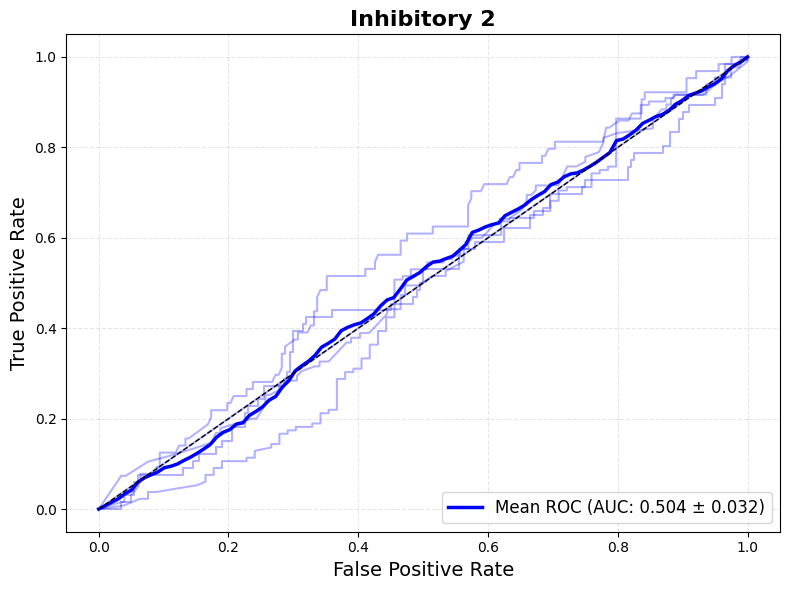

 Inhibitory 3: All splits present


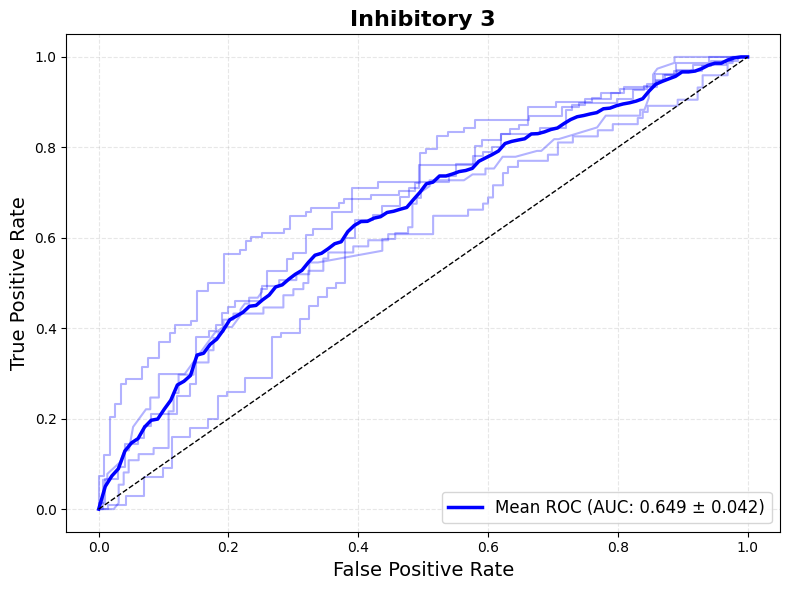

 Inhibitory 4: All splits present


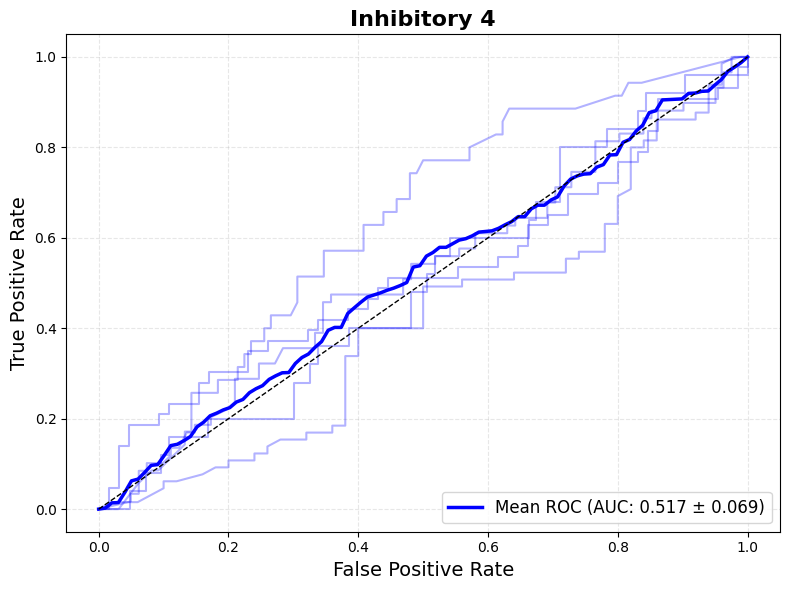

 Inhibitory 5: All splits present


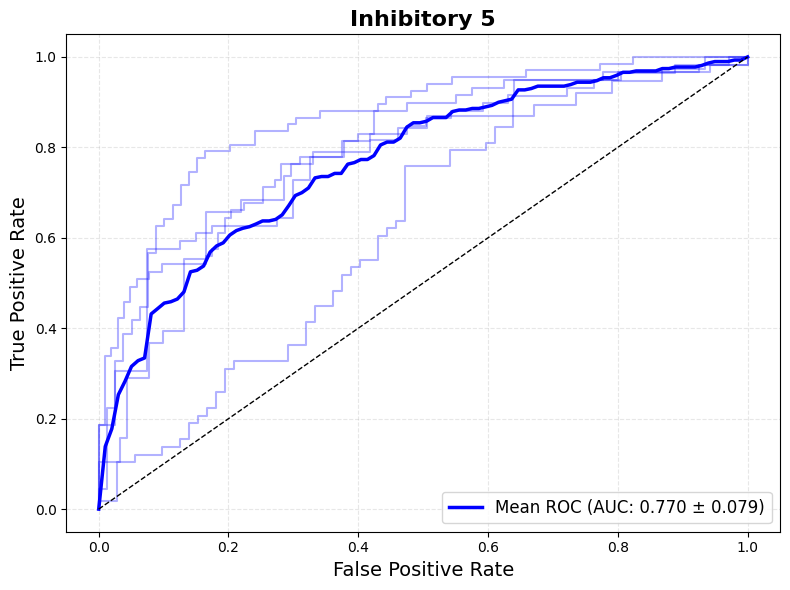

 Inhibitory 6: All splits present


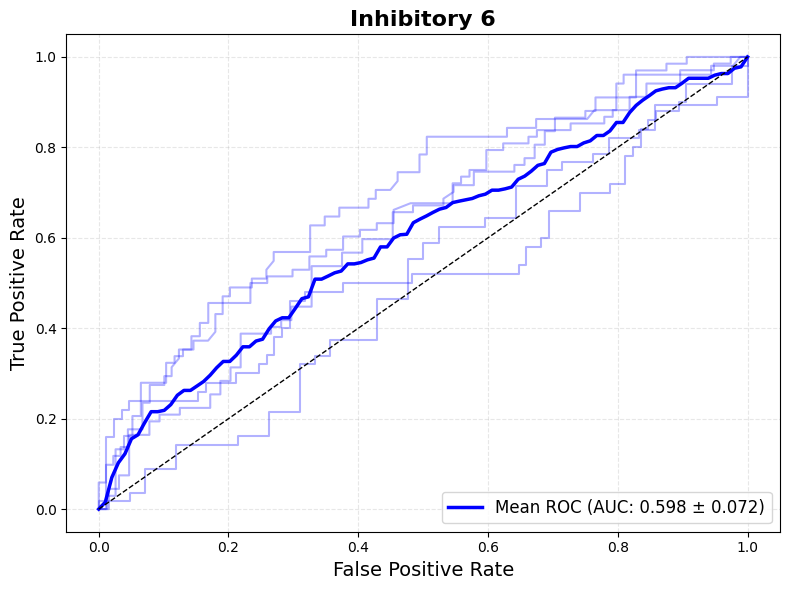

 Inhibitory 7: All splits present


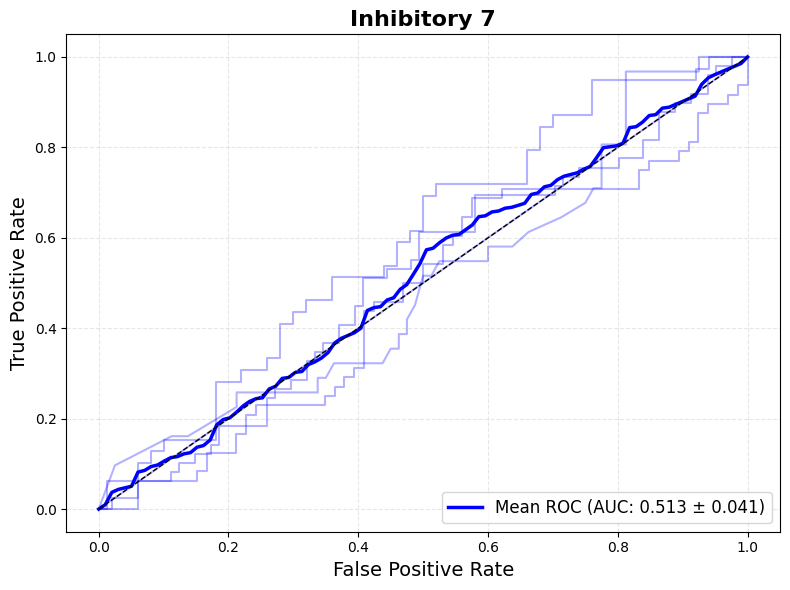

 Inhibitory 8: All splits present


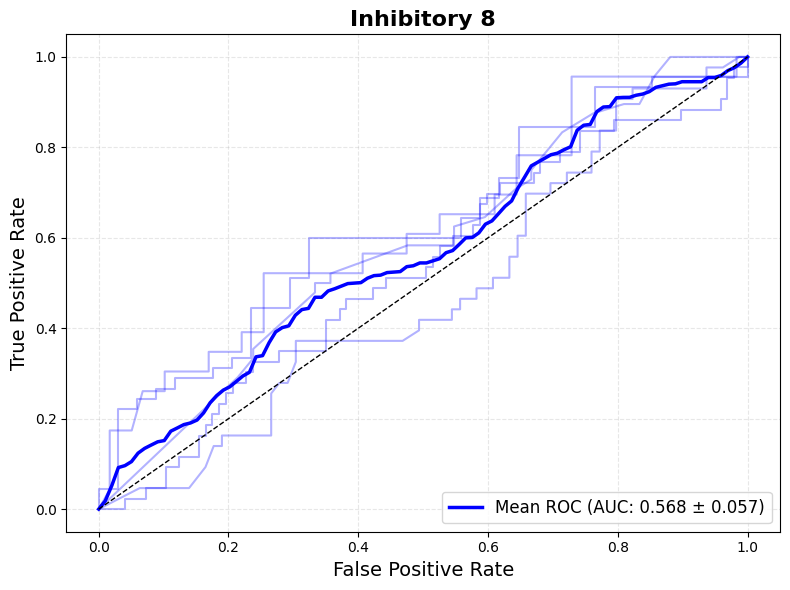

 Inhibitory 9: All splits present


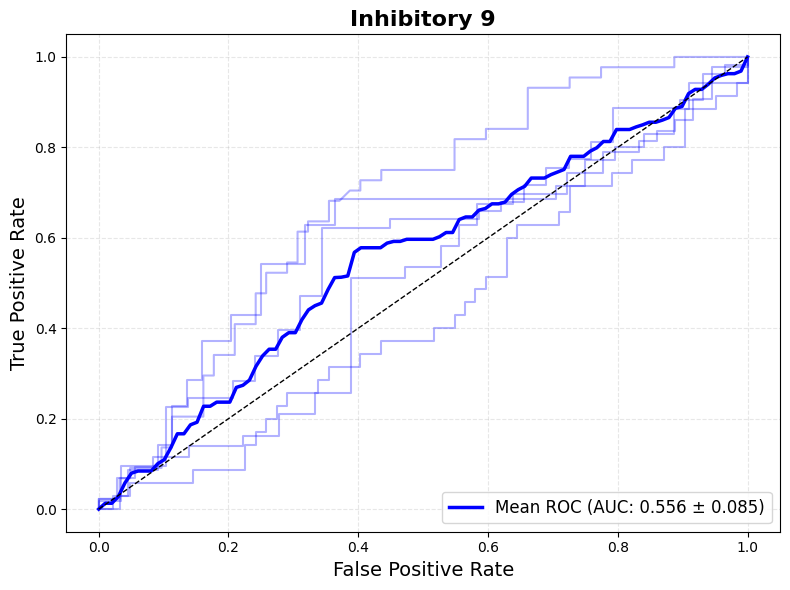

 Inhibitory 10: All splits present


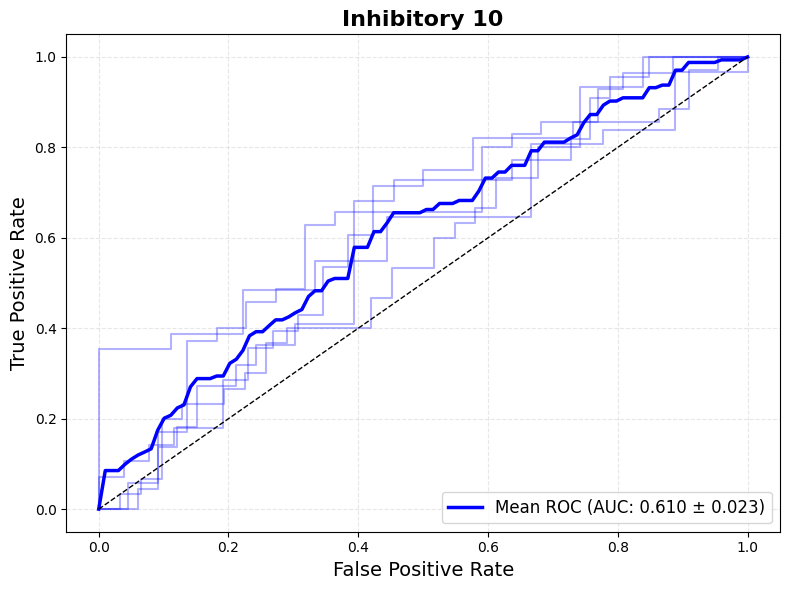

 Inhibitory 11: All splits present


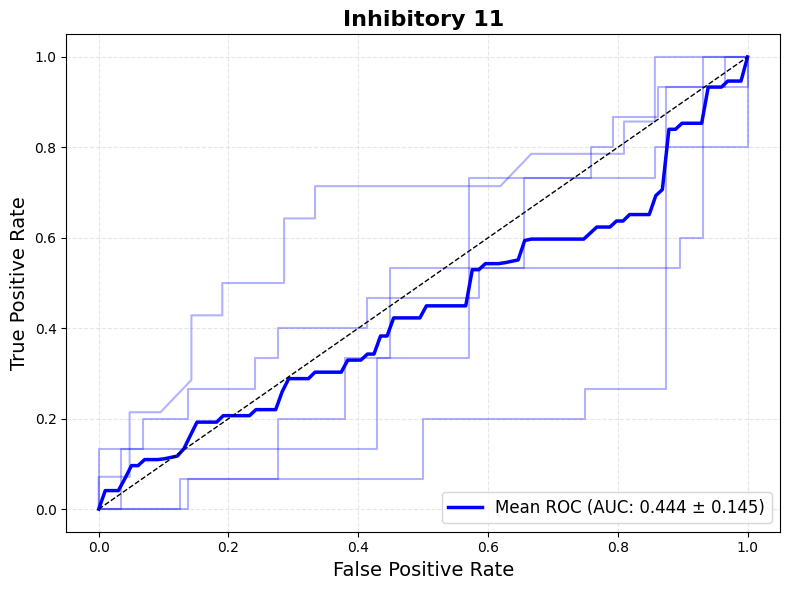

 Microglia 0: All splits present


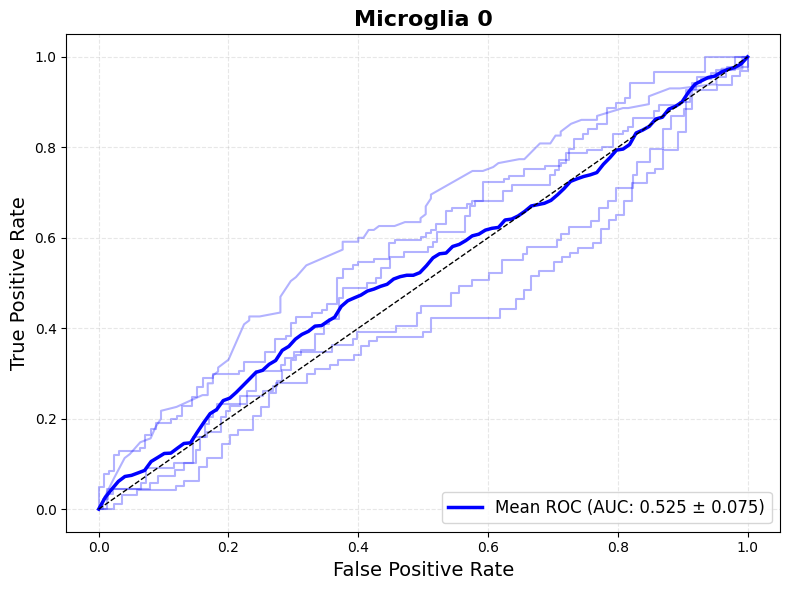

 Microglia 1: All splits present


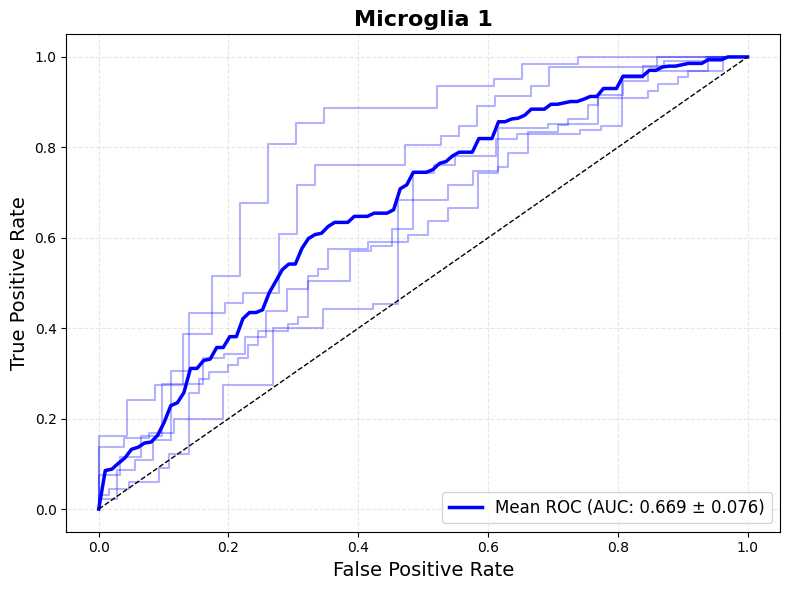

 Microglia 2: All splits present


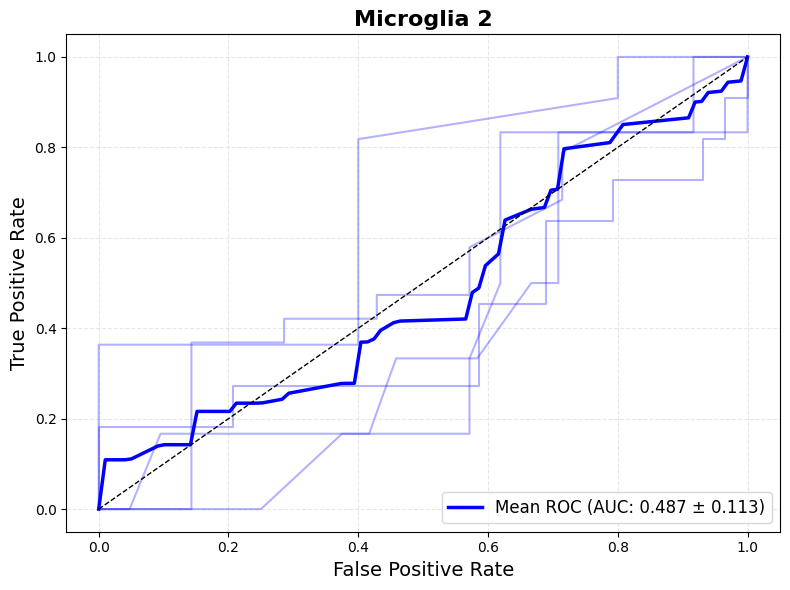

 Microglia 3: All splits present


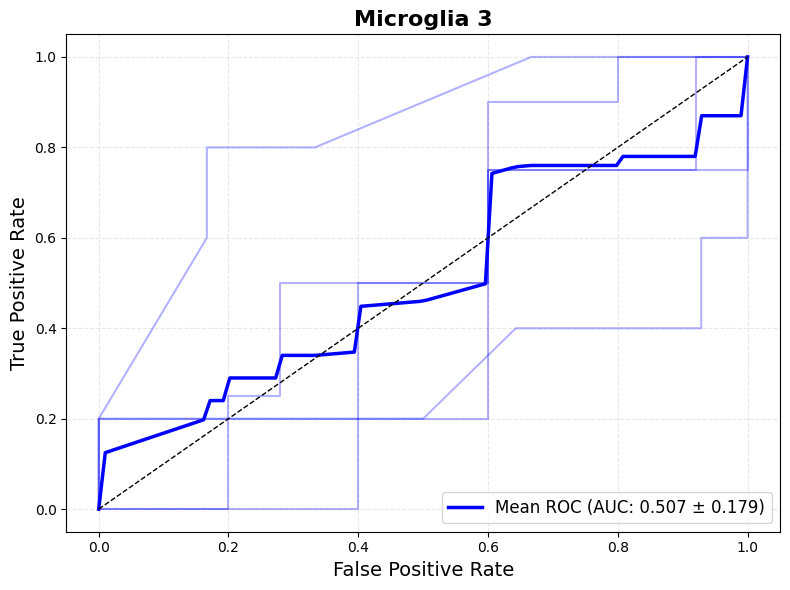

 Oligodendrocytes 0: All splits present


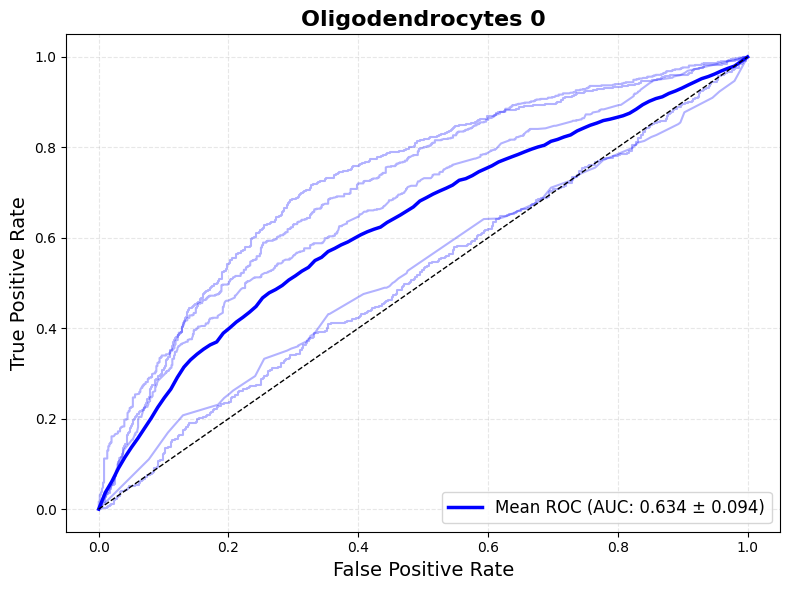

 Oligodendrocytes 1: All splits present


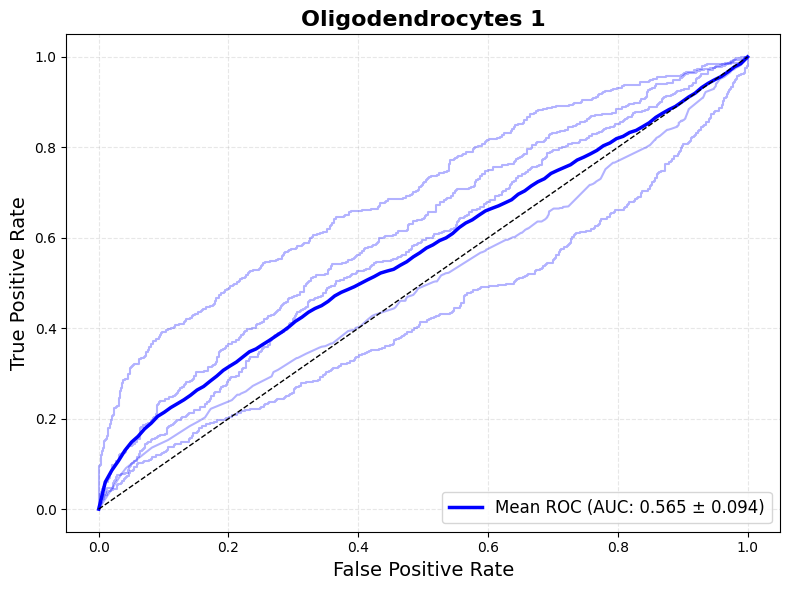

 Oligodendrocytes 3: All splits present


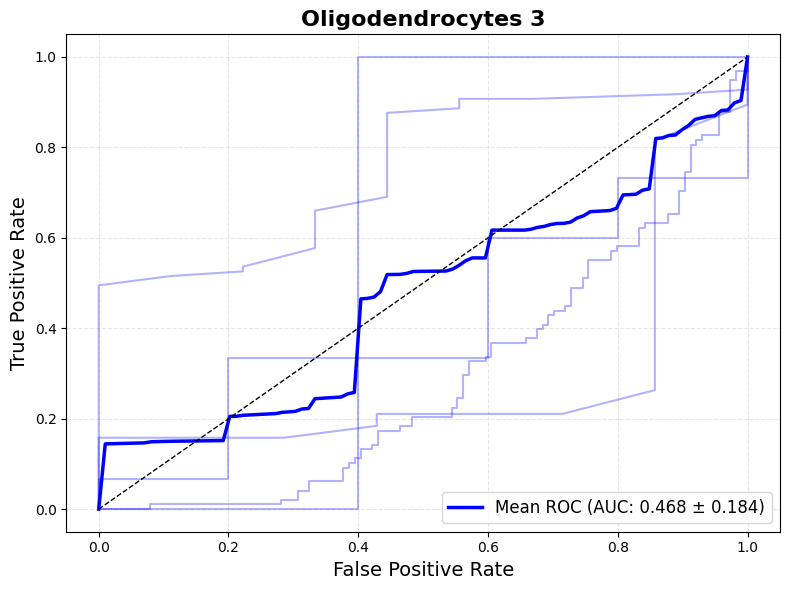

 Oligodendrocytes 4: All splits present


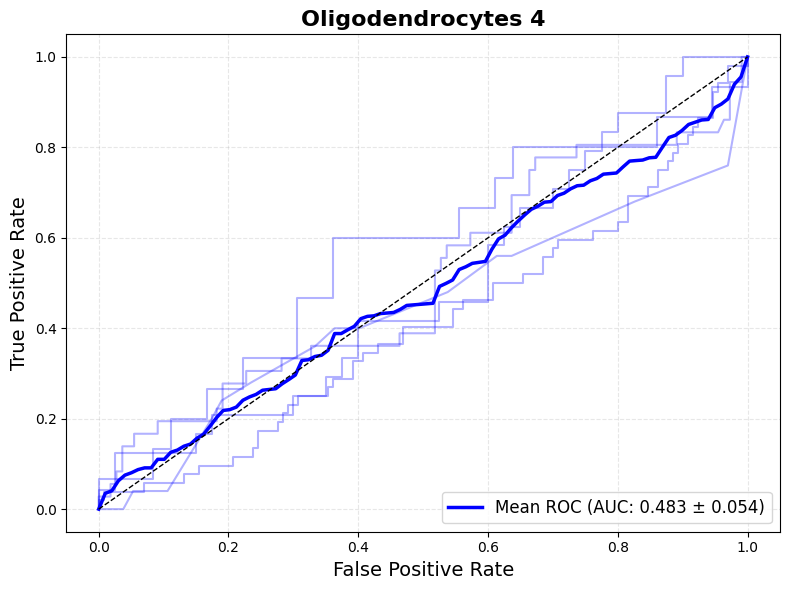

 Oligodendrocytes 5: All splits present


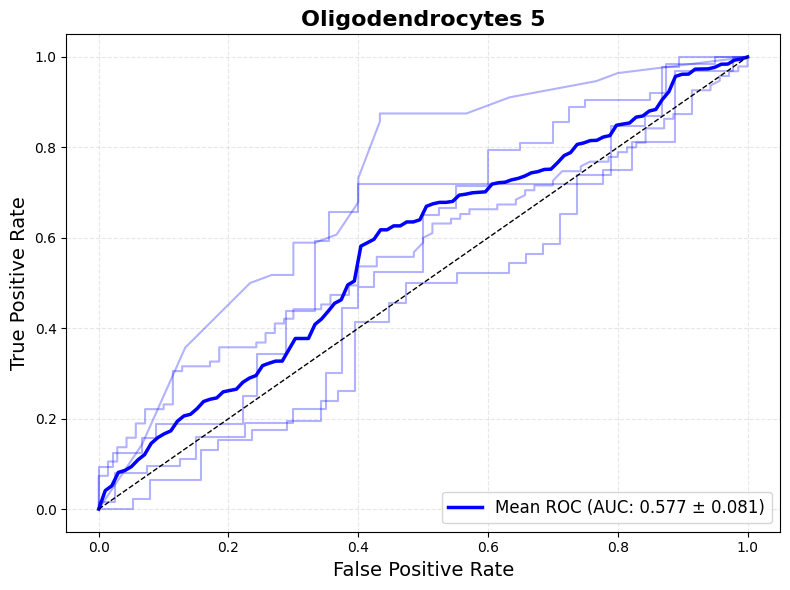

 OPCs 0: All splits present


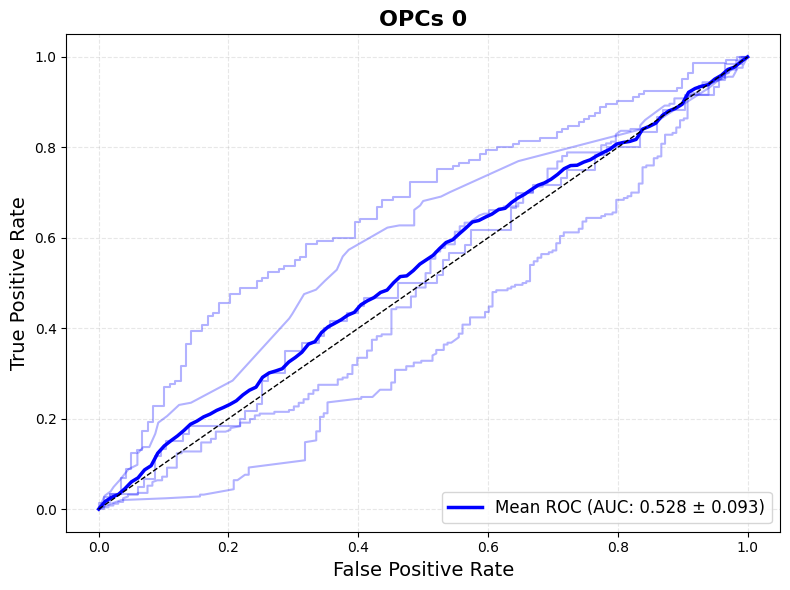

 OPCs 1: All splits present


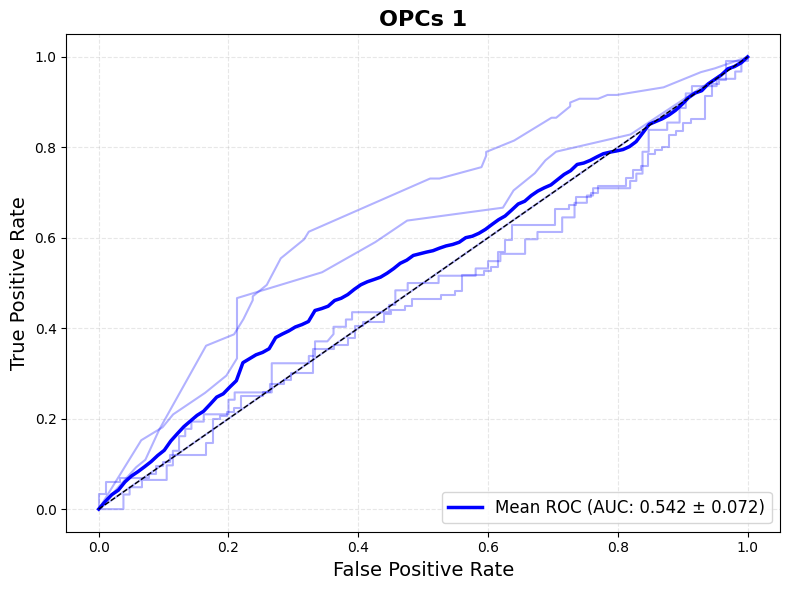

 OPCs 2: Missing splits [3]
⚠️  Split 1 has only one class — skipping
⚠️  Missing: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_genes_subcluster_new/Opc2/split_3/test_predictions.csv
⚠️  Split 4 has only one class — skipping


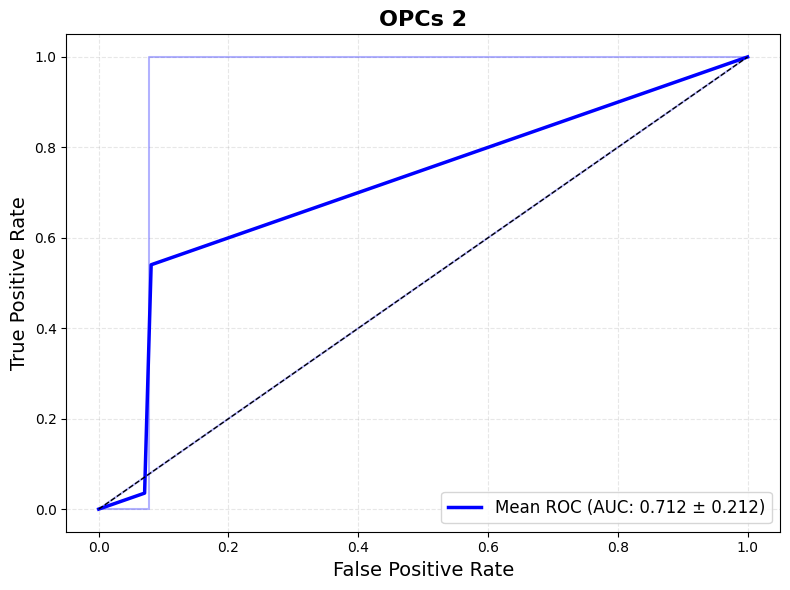

Top 5 subclusters by mean AUC:
Inhibitory 5 (In5): 0.770
OPCs 2 (Opc2): 0.712
Excitatory 6 (Ex6): 0.704
Microglia 1 (Mic1): 0.669
Inhibitory 3 (In3): 0.649
Astrocytes 2 (Ast2): 0.634
Oligodendrocytes 0 (Oli0): 0.634
Excitatory 0 (Ex0): 0.618


In [3]:
subclusters = [
    ("Ast0", "Astrocytes 0"),
    ("Ast1", "Astrocytes 1"),
    ("Ast2", "Astrocytes 2"),
    ("Ast3", "Astrocytes 3"),
    
    ("Ex0", "Excitatory 0"),
    ("Ex1", "Excitatory 1"),
    ("Ex2", "Excitatory 2"),
    ("Ex3", "Excitatory 3"),
    ("Ex4", "Excitatory 4"),
    ("Ex5", "Excitatory 5"),
    ("Ex6", "Excitatory 6"),
    ("Ex7", "Excitatory 7"),
    ("Ex8", "Excitatory 8"),
    ("Ex9", "Excitatory 9"),
    ("Ex11", "Excitatory 11"),
    ("Ex12", "Excitatory 12"),
    ("Ex14", "Excitatory 14"),
    
    ("In0", "Inhibitory 0"),
    ("In1", "Inhibitory 1"),
    ("In2", "Inhibitory 2"),
    ("In3", "Inhibitory 3"),
    ("In4", "Inhibitory 4"),
    ("In5", "Inhibitory 5"),
    ("In6", "Inhibitory 6"),
    ("In7", "Inhibitory 7"),
    ("In8", "Inhibitory 8"),
    ("In9", "Inhibitory 9"),
    ("In10", "Inhibitory 10"),
    ("In11", "Inhibitory 11"),
    
    ("Mic0", "Microglia 0"),
    ("Mic1", "Microglia 1"),
    ("Mic2", "Microglia 2"),
    ("Mic3", "Microglia 3"),
    
    ("Oli0", "Oligodendrocytes 0"),
    ("Oli1", "Oligodendrocytes 1"),
    ("Oli3", "Oligodendrocytes 3"),
    ("Oli4", "Oligodendrocytes 4"),
    ("Oli5", "Oligodendrocytes 5"),
    
    ("Opc0", "OPCs 0"),
    ("Opc1", "OPCs 1"),
    ("Opc2", "OPCs 2"),
]

results = []

for sub, name in subclusters:
    save_path = f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/{sub}"
    auc_value = plot_roc_with_mean_curve(sub, subcluster_name=name, color='blue', save_dir=save_path)
    results.append((sub, name, auc_value))

# Filter out any None values
results = [r for r in results if r[2] is not None]

# Sort by AUC descending
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

# Top 4 subclusters
print("Top 5 subclusters by mean AUC:")
for sub, name, auc_val in results_sorted[:8]:
    print(f"{name} ({sub}): {auc_val:.3f}")

In5: 371 significant marker genes
 Saved In5 pathway results to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/In5_pathways.csv
Opc2: 132 significant marker genes
 Saved Opc2 pathway results to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Opc2_pathways.csv
Ex6: 879 significant marker genes
 Saved Ex6 pathway results to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Ex6_pathways.csv
Mic1: 77 significant marker genes
 Saved Mic1 pathway results to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Mic1_pathways.csv
In3: 193 significant marker genes
 Saved In3 pathway results to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final

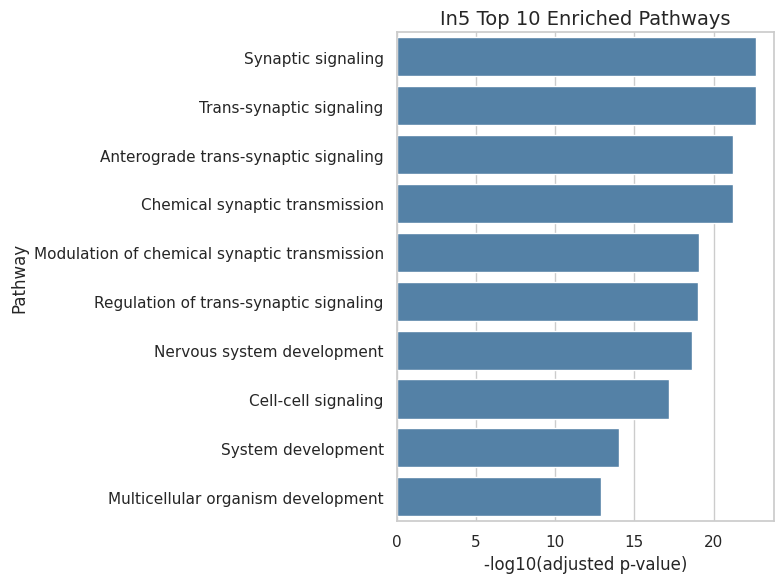

 Saved plot for In5 to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/In5_pathways_plot.png


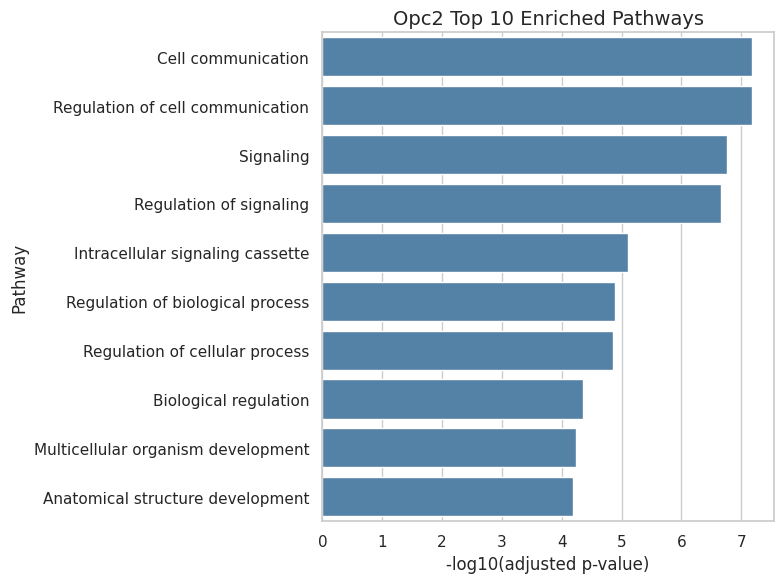

 Saved plot for Opc2 to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Opc2_pathways_plot.png


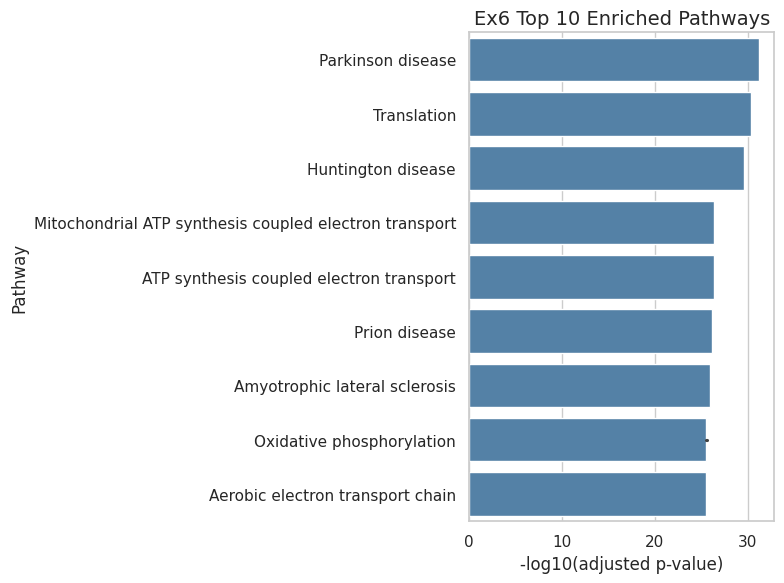

 Saved plot for Ex6 to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Ex6_pathways_plot.png


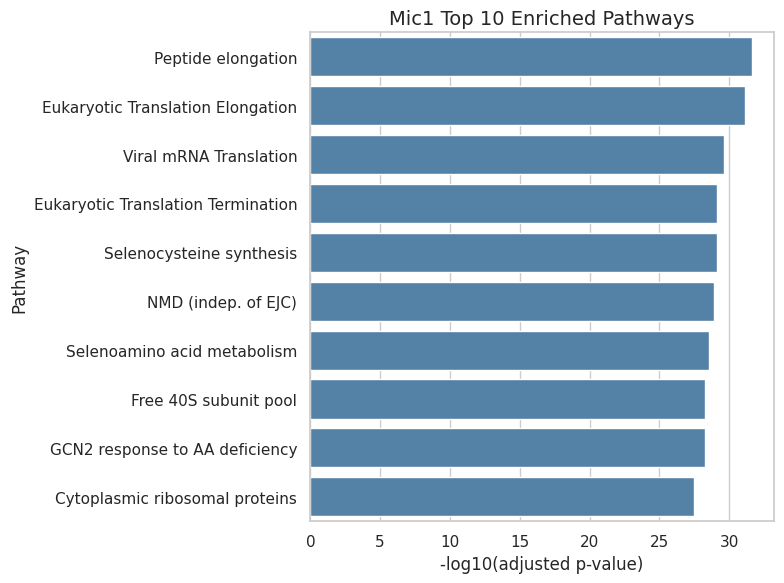

 Saved plot for Mic1 to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Mic1_pathways_plot.png


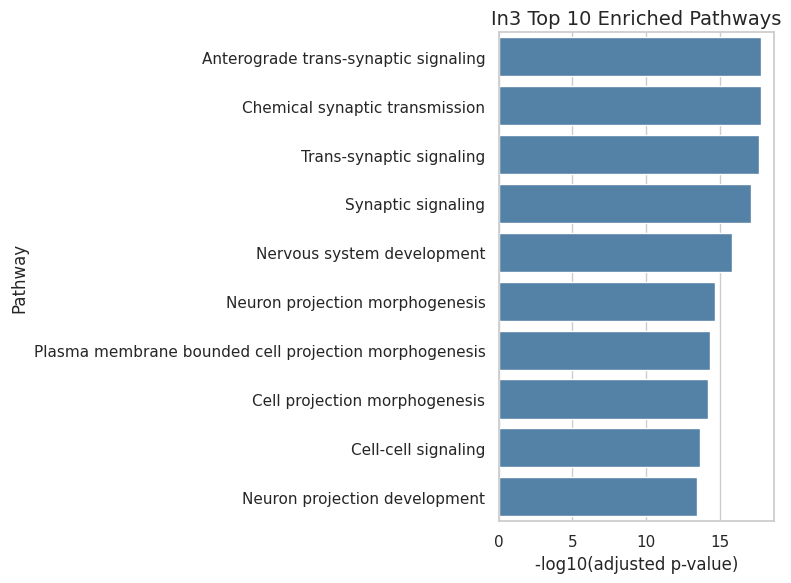

 Saved plot for In3 to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/In3_pathways_plot.png


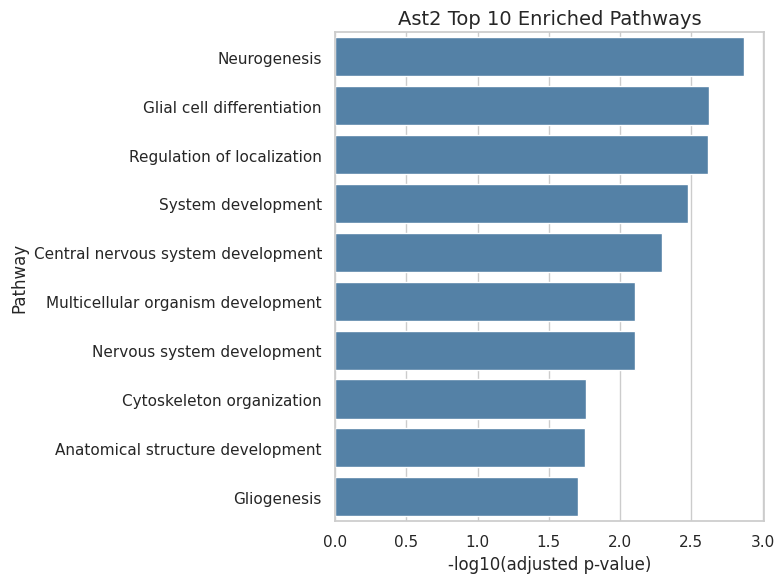

 Saved plot for Ast2 to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Ast2_pathways_plot.png


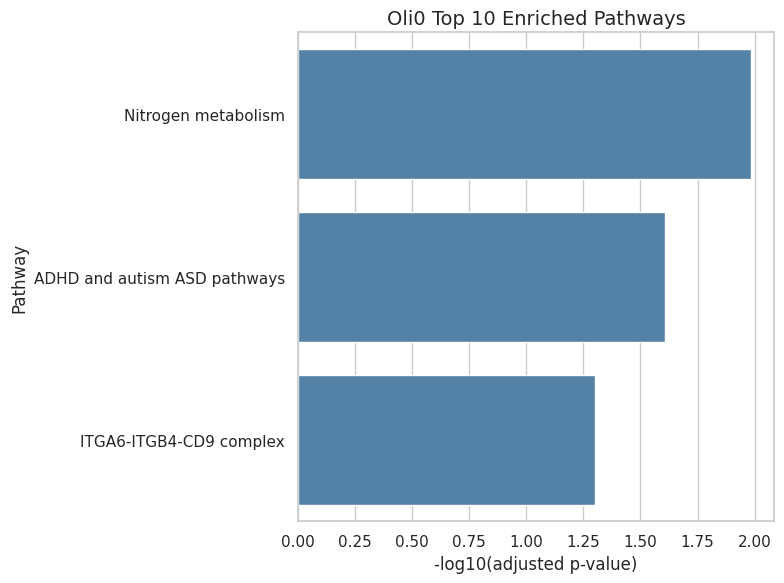

 Saved plot for Oli0 to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways/Oli0_pathways_plot.png


In [ ]:
import pandas as pd
import os
from gprofiler import GProfiler

# === Paths ===
mathys_marker_path = "/n/scratch/users/a/adm808/Mathys_markers.xlsx"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure5/Mathys_Subcluster_Marker_Pathways"
os.makedirs(out_dir, exist_ok=True)

# === Load Mathys marker gene table ===
df = pd.read_excel(mathys_marker_path, header=1)

# Clean up subcluster and adjust column names
df = df.rename(columns={
    "gene.name": "gene",
    "adj.pvals": "adj_pval",
    "lFC": "logFC",
    "subpopulation": "subcluster"
})

# === Define target subclusters ===
target_subclusters = [
    "In5", "Opc2", "Ex6", "Mic1", "In3", "Ast2", "Oli0"
]

# === Initialize g:Profiler ===
gp = GProfiler(return_dataframe=True)

# === Loop through each subcluster and run enrichment ===
for sub in target_subclusters:
    sub_df = df[(df["subcluster"] == sub) & (df["adj_pval"] < 0.05)]
    genes = sub_df["gene"].dropna().unique().tolist()

    print(f"{sub}: {len(genes)} significant marker genes")

    if len(genes) == 0:
        print(f"Skipping {sub}, no significant genes found.")
        continue

    # Run enrichment
    result = gp.profile(organism='hsapiens', query=genes, user_threshold=0.05, sources=['GO:BP', 'KEGG', 'REAC', 'WP', 'HP', 'OMIM', 'CORUM'])

    # Save output
    out_path = os.path.join(out_dir, f"{sub}_pathways.csv")
    result.to_csv(out_path, index=False)

    print(f" Saved {sub} pathway results to {out_path}")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def shorten_and_capitalize(name):
    # Use custom shortened name if available
    name = custom_labels.get(name, name)
    # Capitalize first word only
    return name[0].upper() + name[1:] if name else name

# Shorten long pathway names manually
custom_labels = {
    "Nonsense Mediated Decay (NMD) independent of the Exon Junction Complex (EJC)": "NMD (indep. of EJC)",
    "Response of EIF2AK4 (GCN2) to amino acid deficiency": "GCN2 response to AA deficiency",
    "Formation of a pool of free 40S subunits": "Free 40S subunit pool",
    "Peptide chain elongation": "Peptide elongation".
    "Adhd and autism ASD pathways"
    # Add more if needed
}



# === Plotting settings ===
sns.set(style="whitegrid")
top_n = 10  # number of top pathways to show per subcluster

for sub in target_subclusters:
    csv_path = os.path.join(out_dir, f"{sub}_pathways.csv")
    if not os.path.exists(csv_path):
        print(f" No results for {sub}, skipping plot.")
        continue

    df_plot = pd.read_csv(csv_path)

    if df_plot.empty:
        print(f" Empty enrichment table for {sub}, skipping.")
        continue

    # Sort by adjusted p-value (padj) and keep top N
    df_plot = df_plot.sort_values(by="p_value").head(top_n).copy()
    df_plot["name"] = df_plot["name"].apply(shorten_and_capitalize)
    # df_plot["name"] = df_plot["name"].str.replace(r"(^\w+)", lambda m: m.group(1).capitalize(), regex=True)
    df_plot["-log10(padj)"] = -np.log10(df_plot["p_value"])
    # df_plot = df_plot[::-1]  # reverse for top-down barplot

    # Plot
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(data=df_plot, x="-log10(padj)", y="name", color="steelblue")
    ax.set_title(f"{sub} Top {top_n} Enriched Pathways", fontsize=14)
    ax.set_xlabel("-log10(adjusted p-value)", fontsize=12)
    ax.set_ylabel("Pathway", fontsize=12)
    plt.tight_layout()
    
    # Save plot
    plot_path = os.path.join(out_dir, f"{sub}_pathways_plot.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()

    print(f" Saved plot for {sub} to {plot_path}")

In [ ]:
# All pseudotime and trajectory inference graphs, images, roc curves, etc were generated via the py script found at trajectory_inference.py